# 01 EDA And Dataset Preparation

This notebook is the first stage of the forecasting pipeline. It loads raw OHLCV data, validates it, creates leakage-safe features and future log-return targets, then saves all artifacts required by the table-model notebook.

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
for candidate in [cwd, cwd / "forecasting", cwd.parent, cwd.parent / "forecasting"]:
    if (candidate / "src" / "stock_forecast").exists():
        PROJECT_DIR = candidate
        break
else:
    raise RuntimeError("Cannot locate forecasting project directory with src/stock_forecast")

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

ARTIFACT_DIR = PROJECT_DIR / "artifacts"
DATA_DIR = ARTIFACT_DIR / "data"
REPORTS_DIR = ARTIFACT_DIR / "reports"
PLOTS_DIR = ARTIFACT_DIR / "plots"
for path in [DATA_DIR, REPORTS_DIR, PLOTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_DIR = {PROJECT_DIR}")

PROJECT_DIR = /home/sapce/forecasting_stock_prices/forecasting


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from stock_forecast.artifacts import save_json, save_table
from stock_forecast.data import load_ohlcv
from stock_forecast.features import get_feature_columns, make_features
from stock_forecast.targets import make_future_return_target

plt.style.use("default")
pd.set_option("display.max_columns", 120)

## Notebook Constants

Change these constants to reconfigure the whole preprocessing stage.

In [3]:
RAW_DATA_PATH = PROJECT_DIR / "data" / "historical_data_1d.csv"
DATA_CONFIG = {
    "date_col": "begin",
    "ticker_col": "name",
    "open_col": "open",
    "high_col": "high",
    "low_col": "low",
    "close_col": "close",
    "volume_col": "volume",
    "sep": ";",
}

HORIZONS = [
    {"name": "week", "horizon": 5},
    {"name": "month", "horizon": 21},
]
HORIZON = HORIZONS[0]["horizon"]  # compatibility for existing week artifacts/reports
TARGET_EXECUTION = "next_open"
MIN_HISTORY = 60
RETURN_LAGS = [1, 2, 3, 5, 10, 20]
ROLLING_WINDOWS = [5, 10, 20, 60]
USE_TECHNICAL_INDICATORS = True

TOP_TICKERS_TO_PLOT = 5
RANDOM_STATE = 42

## Load And Validate OHLCV

In [4]:
clean_ohlcv = load_ohlcv(RAW_DATA_PATH, DATA_CONFIG)
clean_path = save_table(clean_ohlcv, DATA_DIR / "clean_ohlcv.parquet")

summary = {
    "rows": int(len(clean_ohlcv)),
    "tickers_count": int(clean_ohlcv["ticker"].nunique()),
    "start_date": clean_ohlcv["date"].min(),
    "end_date": clean_ohlcv["date"].max(),
    "saved_to": str(clean_path.relative_to(PROJECT_DIR)),
}
print(summary)
display(clean_ohlcv.head())
display(clean_ohlcv.groupby("ticker")["date"].agg(["min", "max", "count"]).sort_values("count", ascending=False))

{'rows': 20426, 'tickers_count': 7, 'start_date': Timestamp('2007-05-28 00:00:00'), 'end_date': Timestamp('2026-06-13 00:00:00'), 'saved_to': 'artifacts/data/clean_ohlcv.parquet'}


,date,ticker,open,high,low,close,volume
0,2015-07-01,CBOM,3.6270,3.740,3.6240,3.6800,22000500
1,2015-07-02,CBOM,3.8000,3.800,3.6240,3.6455,27706400
2,2015-07-03,CBOM,3.7250,3.725,3.6315,3.6370,38211300
3,2015-07-06,CBOM,3.6405,3.670,3.6400,3.6700,8407400
4,2015-07-07,CBOM,3.8000,3.800,3.6310,3.6310,30483800


,min,max,count
ticker,,,
SBER,2007-07-20,2026-06-13,4838
SBERP,2007-07-20,2026-06-13,4838
VTBR,2007-05-28,2026-06-13,4794
CBOM,2015-07-01,2026-06-13,2856
T,2019-10-28,2026-06-13,1731
SVCB,2023-12-15,2026-06-13,734
MBNK,2024-04-26,2026-06-13,635


## Missing Values And Basic Quality Checks

In [5]:
missing = clean_ohlcv.isna().sum().rename("missing_count").to_frame()
missing["missing_share"] = missing["missing_count"] / len(clean_ohlcv)
display(missing)

duplicate_count = int(clean_ohlcv.duplicated(["ticker", "date"]).sum())
non_positive_close = int((clean_ohlcv["close"] <= 0).sum())
print({"duplicate_ticker_dates": duplicate_count, "non_positive_close": non_positive_close})

,missing_count,missing_share
date,0,0.0
ticker,0,0.0
open,0,0.0
high,0,0.0
low,0,0.0
close,0,0.0
volume,0,0.0


{'duplicate_ticker_dates': 0, 'non_positive_close': 0}


## Close And Volume Dynamics

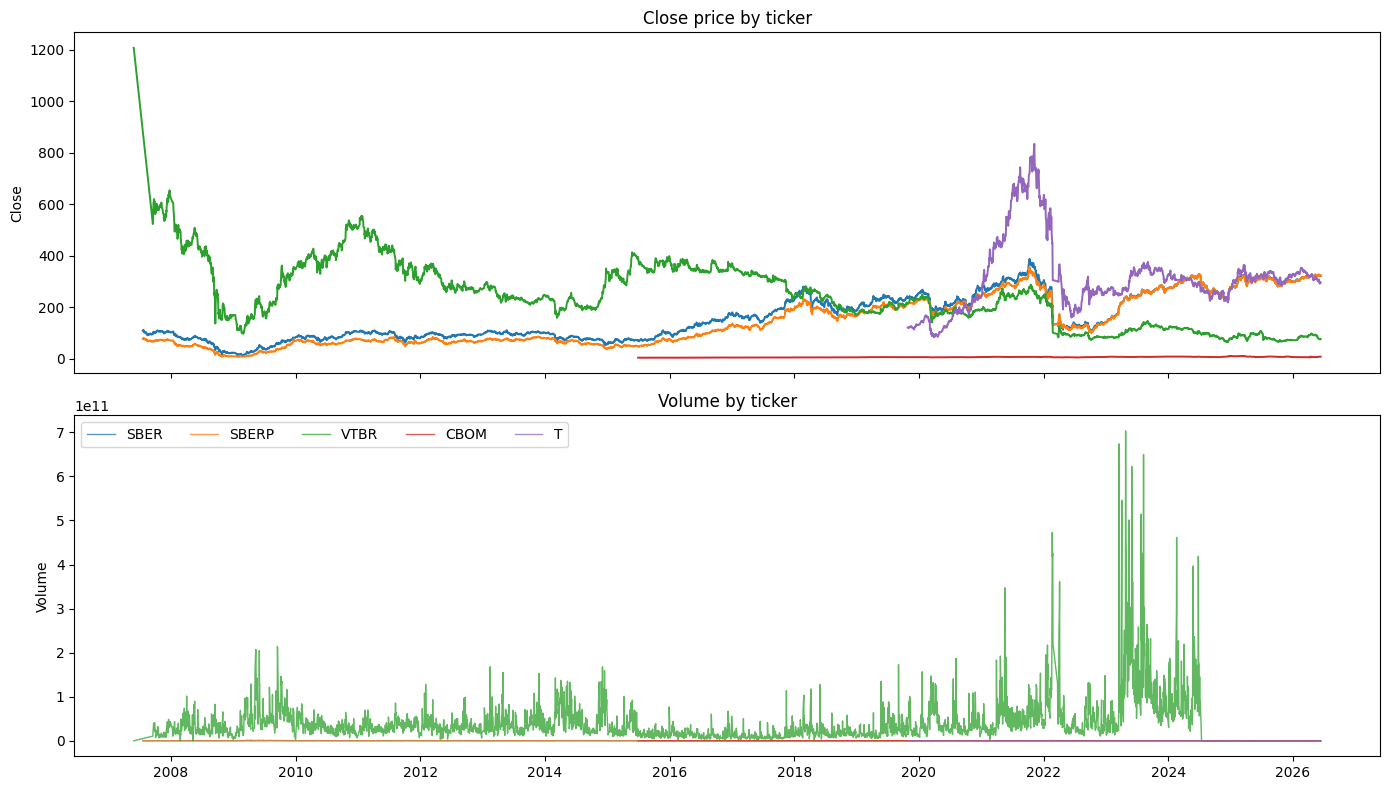

In [6]:
top_tickers = clean_ohlcv["ticker"].value_counts().head(TOP_TICKERS_TO_PLOT).index.tolist()
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ticker in top_tickers:
    part = clean_ohlcv[clean_ohlcv["ticker"] == ticker]
    axes[0].plot(part["date"], part["close"], label=ticker, linewidth=1.4)
    axes[1].plot(part["date"], part["volume"], label=ticker, linewidth=1.0, alpha=0.75)
axes[0].set_title("Close price by ticker")
axes[0].set_ylabel("Close")
axes[1].set_title("Volume by ticker")
axes[1].set_ylabel("Volume")
axes[1].legend(ncol=min(len(top_tickers), 5))
fig.tight_layout()
fig.savefig(PLOTS_DIR / "eda_close_volume.png", dpi=150, bbox_inches="tight")
plt.show()

## Returns Distribution And Correlations

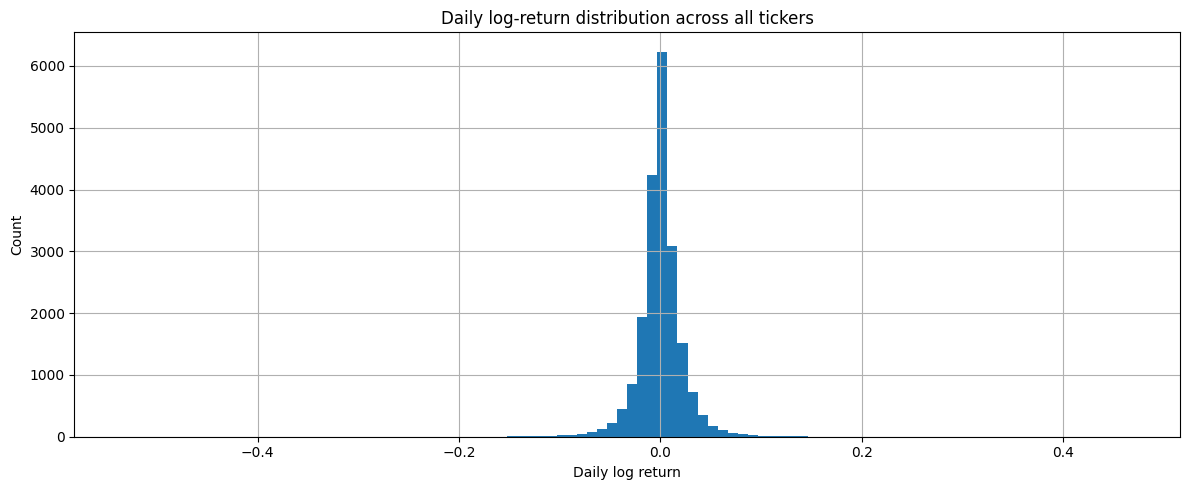

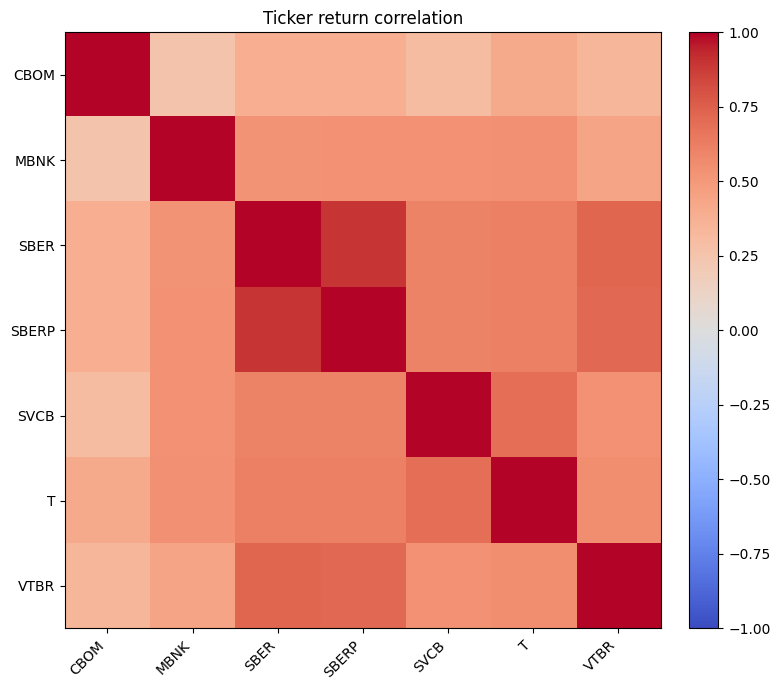

ticker,CBOM,MBNK,SBER,SBERP,SVCB,T,VTBR
ticker,,,,,,,
CBOM,1.000,0.256,0.388,0.384,0.304,0.411,0.340
MBNK,0.256,1.000,0.525,0.536,0.536,0.543,0.441
SBER,0.388,0.525,1.000,0.893,0.605,0.612,0.723
SBERP,0.384,0.536,0.893,1.000,0.605,0.615,0.713
SVCB,0.304,0.536,0.605,0.605,1.000,0.693,0.537
T,0.411,0.543,0.612,0.615,0.693,1.000,0.553
VTBR,0.340,0.441,0.723,0.713,0.537,0.553,1.000


In [7]:
close_pivot = clean_ohlcv.pivot(index="date", columns="ticker", values="close").sort_index()
returns = np.log(close_pivot / close_pivot.shift(1))

fig, ax = plt.subplots(figsize=(12, 5))
returns.stack().dropna().hist(ax=ax, bins=100)
ax.set_title("Daily log-return distribution across all tickers")
ax.set_xlabel("Daily log return")
ax.set_ylabel("Count")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "eda_return_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

corr = returns.corr()
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Ticker return correlation")
fig.tight_layout()
fig.savefig(PLOTS_DIR / "eda_return_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

display(corr.round(3))

## Leakage-Safe Features And Future Return Target

Features use current and past rows only. The only negative shift is used in target creation.

In [8]:
def target_column_for_horizon(horizon: int) -> str:
    suffix = "_next_open" if TARGET_EXECUTION == "next_open" else ""
    return f"target_return_{horizon}{suffix}"


featured = make_features(
    clean_ohlcv,
    return_lags=RETURN_LAGS,
    rolling_windows=ROLLING_WINDOWS,
    use_technical_indicators=USE_TECHNICAL_INDICATORS,
)
feature_cols = get_feature_columns(featured)

if MIN_HISTORY:
    featured["_history_count"] = featured.groupby("ticker").cumcount() + 1
    featured = featured[featured["_history_count"] >= MIN_HISTORY].drop(columns="_history_count")

horizon_datasets = {}
horizon_artifacts = []
model_dataset = None
model_path = None
target_col = None

for spec in HORIZONS:
    horizon_name = spec["name"]
    horizon = int(spec["horizon"])
    horizon_featured = make_future_return_target(featured, horizon=horizon, execution_timing=TARGET_EXECUTION)
    horizon_target_col = target_column_for_horizon(horizon)
    horizon_model_dataset = horizon_featured.dropna(subset=[horizon_target_col, *feature_cols]).reset_index(drop=True)

    horizon_dir = DATA_DIR / "horizons" / horizon_name
    horizon_model_path = save_table(horizon_model_dataset, horizon_dir / "model_dataset.parquet")
    horizon_feature_payload = {
        "horizon_name": horizon_name,
        "horizon": horizon,
        "feature_columns": feature_cols,
        "target_column": horizon_target_col,
        "target_execution": TARGET_EXECUTION,
    }
    save_json(horizon_feature_payload, horizon_dir / "feature_columns.json")

    horizon_datasets[horizon_name] = horizon_model_dataset
    horizon_artifacts.append(
        {
            "horizon_name": horizon_name,
            "horizon": horizon,
            "rows_model_dataset": int(len(horizon_model_dataset)),
            "target_column": horizon_target_col,
            "model_dataset": str(horizon_model_path.relative_to(PROJECT_DIR)),
            "feature_columns": str((horizon_dir / "feature_columns.json").relative_to(PROJECT_DIR)),
        }
    )

    if horizon_name == "week":
        model_dataset = horizon_model_dataset
        target_col = horizon_target_col
        model_path = save_table(model_dataset, DATA_DIR / "model_dataset.parquet")
        save_json(horizon_feature_payload, DATA_DIR / "feature_columns.json")

if model_dataset is None:
    first = horizon_artifacts[0]
    model_dataset = horizon_datasets[first["horizon_name"]]
    target_col = first["target_column"]
    model_path = DATA_DIR / "horizons" / first["horizon_name"] / "model_dataset.parquet"

feature_availability = featured[feature_cols].notna().mean().sort_values().rename("availability").to_frame()
display(feature_availability.head(15))
display(pd.DataFrame(horizon_artifacts))
display(model_dataset[["date", "ticker", "close", "entry_open", "future_open", target_col, *feature_cols[:8]]].head())
print({"features_count": len(feature_cols), "horizons": [spec["name"] for spec in HORIZONS], "compat_saved_to": str(model_path.relative_to(PROJECT_DIR))})

,availability
log_volume_z_abs_ret_z_60,0.983011
signed_volume_shock_60,0.983361
volume_shock_abs_ret_60,0.983361
log_volume_z_60,0.983361
cs_volume_shock_rank_60,0.983361
cs_volume_shock_pct_rank_60,0.983361
macd_hist_over_close_z_60,0.988458
log_volume_z_abs_ret_z_20,0.994004
cs_volume_shock_rank_20,0.994004
cs_volume_shock_pct_rank_20,0.994004


,horizon_name,horizon,rows_model_dataset,target_column,model_dataset,feature_columns
0,week,5,19407,target_return_5_next_open,artifacts/data/horizons/week/model_dataset.par...,artifacts/data/horizons/week/feature_columns.json
1,month,21,19295,target_return_21_next_open,artifacts/data/horizons/month/model_dataset.pa...,artifacts/data/horizons/month/feature_columns....


,date,ticker,close,entry_open,future_open,target_return_5_next_open,log_close,ret_1,open_close_ret,high_low_range,close_to_high,close_to_low,ret_lag_1,ret_lag_2
0,2015-11-09,CBOM,3.750,3.730,3.780,0.013316,1.321756,-0.003992,0.000000,0.000000,0.000000,0.000000,-0.001327,0.000000
1,2015-11-10,CBOM,3.745,3.730,3.805,0.019908,1.320422,-0.001334,0.004013,0.004005,0.000000,0.004021,-0.003992,-0.001327
2,2015-11-11,CBOM,3.740,3.755,3.775,0.005312,1.319086,-0.001336,0.002677,0.002674,0.000000,0.002681,-0.001334,-0.003992
3,2015-11-12,CBOM,3.755,3.760,3.800,0.010582,1.323088,0.004003,0.000000,0.000000,0.000000,0.000000,-0.001336,-0.001334
4,2015-11-13,CBOM,3.780,3.780,3.770,-0.002649,1.329724,0.006636,0.005305,0.300265,-0.227783,0.005319,0.004003,-0.001336


{'features_count': 127, 'horizons': ['week', 'month'], 'compat_saved_to': 'artifacts/data/model_dataset.parquet'}


## Save EDA Summary

In [9]:
eda_summary = {
    "raw_data_path": str(RAW_DATA_PATH),
    "rows_clean": int(len(clean_ohlcv)),
    "rows_model_dataset": int(len(model_dataset)),
    "rows_model_dataset_by_horizon": {
        item["horizon_name"]: item["rows_model_dataset"] for item in horizon_artifacts
    },
    "tickers_count": int(clean_ohlcv["ticker"].nunique()),
    "start_date": clean_ohlcv["date"].min(),
    "end_date": clean_ohlcv["date"].max(),
    "horizon": HORIZON,
    "horizons": HORIZONS,
    "target_execution": TARGET_EXECUTION,
    "min_history": MIN_HISTORY,
    "feature_count": len(feature_cols),
    "feature_columns": feature_cols,
    "target_column": target_col,
    "target_columns_by_horizon": {
        item["horizon_name"]: item["target_column"] for item in horizon_artifacts
    },
    "artifacts": {
        "clean_ohlcv": str(clean_path.relative_to(PROJECT_DIR)),
        "model_dataset": str(model_path.relative_to(PROJECT_DIR)),
        "feature_columns": "artifacts/data/feature_columns.json",
        "horizons": horizon_artifacts,
    },
}
save_json(eda_summary, REPORTS_DIR / "eda_summary.json")
display(pd.Series({k: v for k, v in eda_summary.items() if k not in {"feature_columns", "artifacts"}}))

raw_data_path                    /home/sapce/forecasting_stock_prices/forecasti...
rows_clean                                                                   20426
rows_model_dataset                                                           19407
rows_model_dataset_by_horizon                      {'week': 19407, 'month': 19295}
tickers_count                                                                    7
start_date                                                     2007-05-28 00:00:00
end_date                                                       2026-06-13 00:00:00
horizon                                                                          5
horizons                         [{'name': 'week', 'horizon': 5}, {'name': 'mon...
target_execution                                                         next_open
min_history                                                                     60
feature_count                                                                  127
targ